# Modelo Variacão 1: DenseNet-169 (Fine-Tuning)

Este notebook define o desempenho utilizando Fine-Tuning nas camadas finais:
- **Arquitetura:** DenseNet-169 (Fine-Tuning no `denseblock4` e `norm5`).
- **Data Augmentation:** Leve + Rotation (Resize, Horizontal Flip e Rotation).
- **Otimizador:** Adam com Differential Learning Rates (1e-5 backbone, 1e-3 classifier).
- **Métricas:** Curvas de aprendizado e Matriz de Confusão inclusas.

In [1]:
# =========================================================
# Setup: Bibliotecas e Reprodutibilidade
# =========================================================
import os, random, warnings, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print(f"Device: {device} | AMP: {use_amp}")

# Diretório para salvar os modelos
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda | AMP: True


In [2]:
# ============================
# Configuração do Dataset
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset')
TRAIN_DIR = DATA_ROOT / "Training"
TEST_DIR  = DATA_ROOT / "Testing"

assert TRAIN_DIR.exists(), f"Pasta {TRAIN_DIR} não encontrada."
assert TEST_DIR.exists(), f"Pasta {TEST_DIR} não encontrada."

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation LEVE + Rotation
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Uso das pastas completas conforme solicitado
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(TEST_DIR,  transform=val_tfms)

class_names = train_ds.classes
print("Classes encontradas:", class_names)
print(f"Qtd Treino: {len(train_ds)} | Qtd Teste/Val: {len(val_ds)}")

batch_size = 32
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Classes encontradas: ['glioma', 'meningioma', 'notumor', 'pituitary']
Qtd Treino: 5600 | Qtd Teste/Val: 1600


In [3]:
# ============================
# Modelo: DenseNet-169 Baseline
# ============================
weights = models.DenseNet169_Weights.IMAGENET1K_V1
model = models.densenet169(weights=weights)

# Fine-Tuning: Descongela o último bloco (denseblock4) e a norm5
# Isso permite que a rede adapte as características de alto nível para RM
for name, param in model.features.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Cabeça treinável com Dropout revertido para 0.2
num_classes = len(class_names)
in_feats = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_feats, num_classes)
)

model = model.to(device)

In [4]:
# ============================
# Otimizador, Scheduler e Early Stopping
# ============================
# Usamos Learning Rates diferentes: menor para o backbone (para não destruir o conhecimento)
# e maior para o classificador que é novo.
optimizer = torch.optim.Adam([
    {'params': model.features.denseblock4.parameters(), 'lr': 1e-5},
    {'params': model.features.norm5.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=4,
    min_lr=1e-6
)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, path="baseline_densenet169.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            # Salva o estado no CPU para evitar problemas de compatibilidade/memória
            self.best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            torch.save(self.best_state, self.path)
            return False
        else:
            self.counter += 1
            return self.counter > self.patience

early_stopper = EarlyStopping(patience=10, min_delta=1e-4, path=str(SAVE_DIR / "variacao1_densenet169.pth"))

In [5]:
# ============================
# Funções de Treino e Plot
# ============================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = model(X)
                loss = criterion(logits, y)

        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc = total_correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average='macro')
    return avg_loss, acc, f1, y_true, y_pred

def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch"); plt.ylabel(ylab); plt.title(title); plt.legend(); plt.show()

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize: cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

In [6]:
# ============================
# Treinamento
# ============================
EPOCHS = 100
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[], "lr":[]}

print("Iniciando treinamento...")
for e in range(1, EPOCHS+1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)

    old_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(va_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    history["lr"].append(current_lr)

    print(f"[{e}/{EPOCHS}] train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f} | lr={current_lr:.2e}")
    if current_lr < old_lr:
        print(f"Scheduler reduziu o learning rate: {old_lr:.2e} -> {current_lr:.2e}")

    if early_stopper.step(va_loss, model):
        print(f"Early stopping ativado na época {e}.")
        break

Iniciando treinamento...
[1/100] train_loss=0.5645 acc=0.7948 | val_loss=0.5504 acc=0.8050 f1=0.8026 | lr=1.00e-05
[2/100] train_loss=0.3023 acc=0.8923 | val_loss=0.4076 acc=0.8569 f1=0.8521 | lr=1.00e-05
[3/100] train_loss=0.2321 acc=0.9159 | val_loss=0.4007 acc=0.8744 f1=0.8706 | lr=1.00e-05
[4/100] train_loss=0.1941 acc=0.9271 | val_loss=0.3821 acc=0.8962 f1=0.8938 | lr=1.00e-05
[5/100] train_loss=0.1543 acc=0.9436 | val_loss=0.3972 acc=0.8931 f1=0.8899 | lr=1.00e-05
[6/100] train_loss=0.1317 acc=0.9530 | val_loss=0.3871 acc=0.9031 f1=0.9005 | lr=1.00e-05
[7/100] train_loss=0.1166 acc=0.9571 | val_loss=0.4815 acc=0.8931 f1=0.8890 | lr=1.00e-05
[8/100] train_loss=0.1169 acc=0.9584 | val_loss=0.4076 acc=0.9181 f1=0.9159 | lr=1.00e-05
[9/100] train_loss=0.0882 acc=0.9702 | val_loss=0.4114 acc=0.9225 f1=0.9203 | lr=1.00e-06
Scheduler reduziu o learning rate: 1.00e-05 -> 1.00e-06
[10/100] train_loss=0.0717 acc=0.9754 | val_loss=0.3912 acc=0.9237 f1=0.9218 | lr=1.00e-06
[11/100] train_los

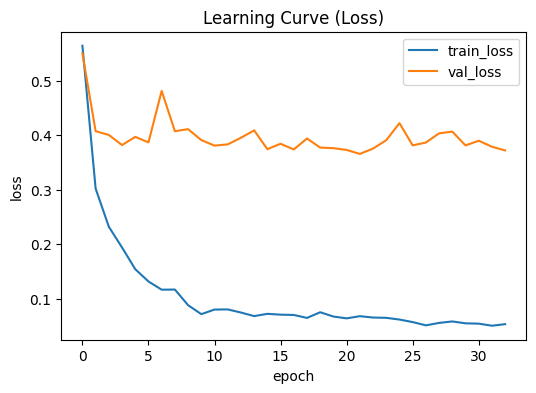

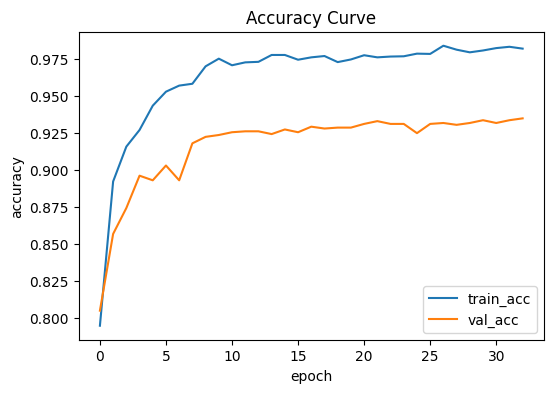

Melhor modelo carregado de ../models/variacao1_densenet169.pth

Melhor F1-Score (Macro): 0.9315

Classification Report:
               precision    recall  f1-score   support

      glioma       0.98      0.79      0.88       400
  meningioma       0.87      0.96      0.91       400
     notumor       0.92      0.99      0.95       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



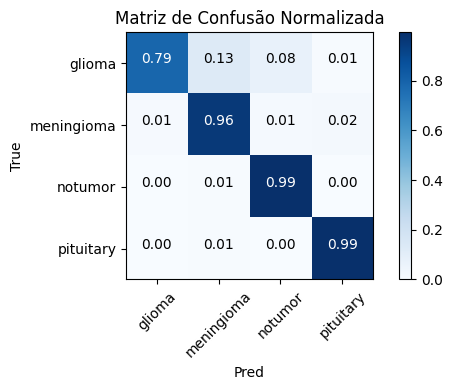

In [7]:
# ============================
# Resultados Finais
# ============================
plot_curve(history, "train_loss", "val_loss", "Learning Curve (Loss)", "loss")
plot_curve(history, "train_acc",  "val_acc",  "Accuracy Curve", "accuracy")

# Carrega o melhor e avalia uma última vez
best_path = SAVE_DIR / "variacao1_densenet169.pth"
if os.path.exists(best_path):
    state = torch.load(best_path, map_location=device)
    model.load_state_dict(state)
    print(f"Melhor modelo carregado de {best_path}")

_, _, val_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

print(f"\nMelhor F1-Score (Macro): {val_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=True, title="Matriz de Confusão Normalizada")